<a href="https://colab.research.google.com/github/aabitokh/home_repo/blob/develop/ML/back_propagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np


#веса первого нейрона (случайнык)
W1 = np.array([[-0.2, 0.3, -0.4],
 [0.1, -0.3, -0.4]])
#веса второго нейрона
W2 = np.array([0.2, 0.3])


#функция активации
def f(x):
    return 2/(1 + np.exp(-x)) - 1

#производная от функции активации
def df(x):
    return 0.5*(1 + x)*(1 - x)

#прогоняем инпут
def go_forward(inp):
    #умножаем входной вектор на матрицу W1 и идем на первый слой
    print(f'умножаем вектор {inp}')
    print(f'веса перед первым слоем {W1}')
    sum = np.dot(W1, inp)

    print(f'получилось такое {sum}, проходит через активацию по элементам')

    #получаем входные значения (просто число) для первого слоя, которые проходят через функцию активации
    #out -- это вектор, который выходит из второго слоя и умножается на матрицу весов следующую за ним
    out = np.array([f(x) for x in sum])
    print(f'и получается {out}')

    sum = np.dot(W2, out)
    print(f'умножаем вектор {out}')
    print(f'веса перед вторым слоем {W2}')
    print(f'получилось такое {sum}')

    y = f(sum)

    print(f'и получается  Y {y}')
    print('*' * 100)
    return (y, out)

def train(epoch):
  global W2, W1
  lmd = 0.01          # шаг обучения
  N = 1          # число итераций при обучении
  count = len(epoch)
  for k in range(N):
    print(k)
    x = epoch[np.random.randint(0, count)]  # случайных выбор входного сигнала из обучающей выборки
    y, out = go_forward(x[0:3])             # прямой проход по НС и вычисление выходных значений нейронов
    print(f'предикшн вышел {y}, а выход с первого слоя {out}')
    e = y - x[-1]                           # ошибка
    print(f'ошибка {e}')

    delta = e*df(y)
    print(f'{delta} а вот дельта = ошибка уможенная на производную функции активации в точке Y')
                        # локальный градиент




    # вот тут корректировка весов проиходит слишком рано, при вычислдении дельты должны быть старые веса

    delta2 = W2*delta*df(out)               # вектор из 2-х величин локальных градиентов

    print(f'delta 2 = {delta2}')

    print(f'веса вторго слоя были {W2}')

    W2[0] = W2[0] - lmd * delta * out[0]    # корректировка веса первой связи
    W2[1] = W2[1] - lmd * delta * out[1]    # корректировка веса второй связи
    print(f'веса вторго слоя стали {W2}')

    # корректировка связей первого слоя
    print(f'веса первого слоя были {W1}')
    print(f'входной вектор был {x[0:3]}')

    W1[0, :] = W1[0, :] - np.array(x[0:3]) * delta2[0] * lmd
    W1[1, :] = W1[1, :] - np.array(x[0:3]) * delta2[1] * lmd

    print(f'веса первого слоя стали {W1}')
    print('>>' * 100)



In [ ]:

# обучающая выборка (она же полная выборка)
epoch = [(-1, -1, -1, -1),
         (-1, -1, 1, 1),
         (-1, 1, -1, -1),
         (-1, 1, 1, 1),
         (1, -1, -1, -1),
         (1, -1, 1, 1),
         (1, 1, -1, -1),
         (1, 1, 1, -1)]

train(epoch)        # запуск обучения сети



0
умножаем вектор (-1, -1, 1)
веса перед первым слоем [[-0.2  0.3 -0.4]
 [ 0.1 -0.3 -0.4]]
получилось такое [-0.5 -0.2], проходит через активацию по элементам
и получается [-0.24491866 -0.09966799]
умножаем вектор [-0.24491866 -0.09966799]
веса перед вторым слоем [0.2 0.3]
получилось такое -0.07888413086822854
и получается  Y -0.039421625121651926
****************************************************************************************************
предикшн вышел -0.039421625121651926, а выход с первого слоя [-0.24491866 -0.09966799]
ошибка -1.039421625121652
-0.5189031484226062 а вот дельта = ошибка уможенная на производную функции активации в точке Y
delta 2 = [-0.04877767 -0.07706228]
веса вторго слоя были [0.2 0.3]
веса вторго слоя стали [0.19872911 0.29948282]
веса первого слоя были [[-0.2  0.3 -0.4]
 [ 0.1 -0.3 -0.4]]
входной вектор был (-1, -1, 1)
веса первого слоя стали [[-0.20048778  0.29951222 -0.39951222]
 [ 0.09922938 -0.30077062 -0.39922938]]
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

Accuracy: 0.98


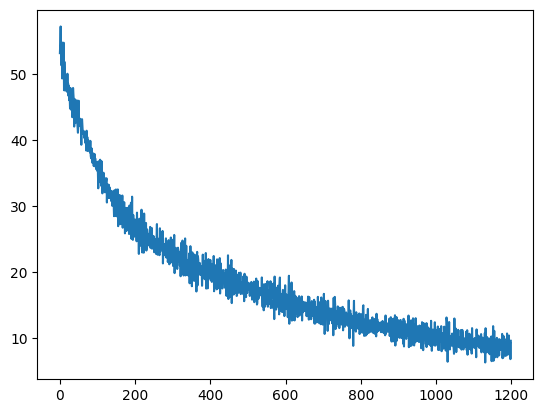

In [ ]:
import random
import numpy as np

INPUT_DIM = 4
OUT_DIM = 3
H_DIM = 10

def relu(t):
    return np.maximum(t, 0)

def softmax(t):
    out = np.exp(t)
    return out / np.sum(out)

def softmax_batch(t):
    out = np.exp(t)
    return out / np.sum(out, axis=1, keepdims=True)

def sparse_cross_entropy(z, y):
    return -np.log(z[0, y])

def sparse_cross_entropy_batch(z, y):
    return -np.log(np.array([z[j, y[j]] for j in range(len(y))]))

def to_full(y, num_classes):
    y_full = np.zeros((1, num_classes))
    y_full[0, y] = 1
    return y_full

def to_full_batch(y, num_classes):
    y_full = np.zeros((len(y), num_classes))
    for j, yj in enumerate(y):
        y_full[j, yj] = 1
    return y_full

def relu_deriv(t):
    return (t >= 0).astype(float)

from sklearn import datasets
iris = datasets.load_iris()
dataset = [(iris.data[i][None, ...], iris.target[i]) for i in range(len(iris.target))]

W1 = np.random.rand(INPUT_DIM, H_DIM)
b1 = np.random.rand(1, H_DIM)
W2 = np.random.rand(H_DIM, OUT_DIM)
b2 = np.random.rand(1, OUT_DIM)

W1 = (W1 - 0.5) * 2 * np.sqrt(1/INPUT_DIM)
b1 = (b1 - 0.5) * 2 * np.sqrt(1/INPUT_DIM)
W2 = (W2 - 0.5) * 2 * np.sqrt(1/H_DIM)
b2 = (b2 - 0.5) * 2 * np.sqrt(1/H_DIM)

ALPHA = 0.0002
NUM_EPOCHS = 400
BATCH_SIZE = 50

loss_arr = []

for ep in range(NUM_EPOCHS):
    random.shuffle(dataset)
    for i in range(len(dataset) // BATCH_SIZE):

        batch_x, batch_y = zip(*dataset[i*BATCH_SIZE : i*BATCH_SIZE+BATCH_SIZE])
        x = np.concatenate(batch_x, axis=0)
        y = np.array(batch_y)

        # Forward
        t1 = x @ W1 + b1
        h1 = relu(t1)
        t2 = h1 @ W2 + b2
        z = softmax_batch(t2)
        E = np.sum(sparse_cross_entropy_batch(z, y))

        # Backward
        y_full = to_full_batch(y, OUT_DIM)
        dE_dt2 = z - y_full
        dE_dW2 = h1.T @ dE_dt2
        dE_db2 = np.sum(dE_dt2, axis=0, keepdims=True)
        dE_dh1 = dE_dt2 @ W2.T
        dE_dt1 = dE_dh1 * relu_deriv(t1)
        dE_dW1 = x.T @ dE_dt1
        dE_db1 = np.sum(dE_dt1, axis=0, keepdims=True)

        # Update
        W1 = W1 - ALPHA * dE_dW1
        b1 = b1 - ALPHA * dE_db1
        W2 = W2 - ALPHA * dE_dW2
        b2 = b2 - ALPHA * dE_db2

        loss_arr.append(E)

def predict(x):
    t1 = x @ W1 + b1
    h1 = relu(t1)
    t2 = h1 @ W2 + b2
    z = softmax_batch(t2)
    return z

def calc_accuracy():
    correct = 0
    for x, y in dataset:
        z = predict(x)
        y_pred = np.argmax(z)
        if y_pred == y:
            correct += 1
    acc = correct / len(dataset)
    return acc

accuracy = calc_accuracy()
print("Accuracy:", accuracy)

import matplotlib.pyplot as plt
plt.plot(loss_arr)
plt.show()

In [ ]:
import numpy as np

INPUT_DIM = 4
OUT_DIM = 3
H_DIM = 10

x = np.array([7.9, 3.1, 7.5, 1.8])

W1 = np.array([[ 0.33462099,  0.10068401,  0.20557238, -0.19043767,  0.40249301, -0.00925352,  0.00628916,  0.74784975,  0.25069956, -0.09290041 ],
               [ 0.41689589,  0.93211640, -0.32300143, -0.13845456,  0.58598293, -0.29140373, -0.28473491,  0.48021000, -0.32318306, -0.34146461 ],
               [-0.21927019, -0.76135162, -0.11721704,  0.92123373,  0.19501658,  0.00904006,  1.03040632, -0.66867859, -0.01571104, -0.08372566 ],
               [-0.67791724,  0.07044558, -0.40981071,  0.62098450, -0.33009159, -0.47352435,  0.09687051, -0.68724299,  0.43823402, -0.26574543 ]])

b1 =  np.array([-0.34133575, -0.24401602, -0.06262318, -0.30410971, -0.37097632,  0.02670964, -0.51851308,  0.54665141,  0.20777536, -0.29905165 ])

W2 = np.array([[ 0.41186367,  0.15406952, -0.47391773 ],
               [ 0.79701137, -0.64672799, -0.06339983 ],
               [-0.20137522, -0.07088810,  0.00212071 ],
               [-0.58743081, -0.17363843,  0.93769169 ],
               [ 0.33262125,  0.18999841, -0.14977653 ],
               [ 0.04450406,  0.26168097,  0.10104333 ],
               [-0.74384144,  0.33092591,  0.65464737 ],
               [ 0.45764631,  0.48877246, -1.16928700 ],
               [-0.16020630, -0.12369116,  0.14171301 ],
               [ 0.26099978,  0.12834471,  0.20866959 ]])

b2 =  np.array([-0.16286677,  0.06680119, -0.03563594 ])

def relu(t):
    return np.maximum(t, 0)

def softmax(t):
    out = np.exp(t)
    return out / np.sum(out)

def predict(x):
    t1 = x @ W1 + b1
    h1 = relu(t1)
    t2 = h1 @ W2 + b2
    z = softmax(t2)
    return z

probs = predict(x)
pred_class = np.argmax(probs)
class_names = ['Setosa', 'Versicolor', 'Virginica']
print('Predicted class:', class_names[pred_class])